# Assignment 2

In this assigment, we will work with the *Forest Fire* data set. Please download the data from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/162/forest+fires). Extract the data files into the subdirectory: `../data/fires/` (relative to `./05_src/`).

## Objective

+ The model objective is to predict the area affected by forest fires given the features set. 
+ The objective of this exercise is to assess your ability to construct and evaluate model pipelines.
+ Please note: the instructions are not meant to be 100% prescriptive, but instead they are a set of minimum requirements. If you find predictive performance gains by applying additional steps, by all means show them. 

## Variable Description

From the description file contained in the archive (`forestfires.names`), we obtain the following variable descriptions:

1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
3. month - month of the year: "jan" to "dec" 
4. day - day of the week: "mon" to "sun"
5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
6. DMC - DMC index from the FWI system: 1.1 to 291.3 
7. DC - DC index from the FWI system: 7.9 to 860.6 
8. ISI - ISI index from the FWI system: 0.0 to 56.10
9. temp - temperature in Celsius degrees: 2.2 to 33.30
10. RH - relative humidity in %: 15.0 to 100
11. wind - wind speed in km/h: 0.40 to 9.40 
12. rain - outside rain in mm/m2 : 0.0 to 6.4 
13. area - the burned area of the forest (in ha): 0.00 to 1090.84 









### Specific Tasks

+ Construct four model pipelines, out of combinations of the following components:

    + Preprocessors:

        - A simple processor that only scales numeric variables and recodes categorical variables.
        - A transformation preprocessor that scales numeric variables and applies a non-linear transformation.
    
    + Regressor:

        - A baseline regressor, which could be a [K-nearest neighbours model]() or a linear model like [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) or [Ridge Regressors](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ridge_regression.html).
        - An advanced regressor of your choice (e.g., Bagging, Boosting, SVR, etc.). TIP: select a tree-based method such that it does not take too long to run SHAP further below. 

+ Evaluate tune and evaluate each of the four model pipelines. 

    - Select a [performance metric](https://scikit-learn.org/stable/modules/linear_model.html) out of the following options: explained variance, max error, root mean squared error (RMSE), mean absolute error (MAE), r-squared.
    - *TIPS*: 
    
        * Out of the suggested metrics above, [some are correlation metrics, but this is a prediction problem](https://www.tmwr.org/performance#performance). Choose wisely (and don't choose the incorrect options.) 

+ Select the best-performing model and explain its predictions.

    - Provide local explanations.
    - Obtain global explanations and recommend a variable selection strategy.

+ Export your model as a pickle file.


You can work on the Jupyter notebook, as this experiment is fairly short (no need to use sacred). 

# Load the data

Place the files in the ../../05_src/data/fires/ directory and load the appropriate file. 

In [213]:
# Load the libraries as required.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap

from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import TransformedTargetRegressor



In [214]:
# Load data
columns = [
    'coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain', 'area' 
]
fires_dt = (pd.read_csv('../../05_src/data/fires/forestfires.csv', header = 0, names = columns))
fires_dt


,coord_x,coord_y,month,day,ffmc,dmc,dc,isi,temp,rh,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.00
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.00
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.00
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.00
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,aug,sun,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,6.44
513,2,4,aug,sun,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,54.29
514,7,4,aug,sun,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,11.16
515,1,4,aug,sat,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,0.00


# Get X and Y

Create the features data frame and target data.

In [215]:
# Separate features and target

X = fires_dt.drop(columns=['area'])
y = fires_dt['area'].values

In [216]:
# Split (train/test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Column lists
numeric_features = ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain']
categorical_features = ['month', 'day']


# Preprocessing

Create two [Column Transformers](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html), called preproc1 and preproc2, with the following guidelines:

- Numerical variables

    * (Preproc 1 and 2) Scaling: use a scaling method of your choice (Standard, Robust, Min-Max). 
    * Preproc 2 only: 
        
        + Choose a transformation for any of your input variables (or several of them). Evaluate if this transformation is convenient.
        + The choice of scaler is up to you.

- Categorical variables: 
    
    * (Preproc 1 and 2) Apply [one-hot encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) where appropriate.


+ The only difference between preproc1 and preproc2 is the non-linear transformation of the numerical variables.
    


### Preproc 1

Create preproc1 below.

+ Numeric: scaled variables, no other transforms.
+ Categorical: one-hot encoding.

In [217]:
from sklearn.preprocessing import StandardScaler

num_pipeline_p1 = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preproc1 = ColumnTransformer([
    ('num', num_pipeline_p1, numeric_features),
    ('cat', cat_pipeline, categorical_features),
], remainder='drop')


### Preproc 2

Create preproc1 below.

+ Numeric: scaled variables, non-linear transformation to one or more variables.
+ Categorical: one-hot encoding.

In [218]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('transform', PowerTransformer(method='yeo-johnson')),  # non-linear transformation
    ('scaler', StandardScaler())                            # scaling step
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preproc2 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

## Model Pipeline


Create a [model pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html): 

+ Add a step labelled `preprocessing` and assign the Column Transformer from the previous section.
+ Add a step labelled `regressor` and assign a regression model to it. 

## Regressor

+ Use a regression model to perform a prediction. 

    - Choose a baseline regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Choose a more advance regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Both model choices are up to you, feel free to experiment.

In [219]:
baseline_regressor = Ridge(random_state=42)
advanced_regressor = RandomForestRegressor(random_state=42, n_jobs=-1)

In [220]:
# Pipeline A = preproc1 + baseline

pipe_A = Pipeline([
    ('preprocessing', preproc1),
    ('regressor', baseline_regressor)
])

pipe_A


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['coord_x', 'coord_y', 'ffmc',
                                                   'dmc', 'dc', 'isi', 'temp',
                                                   'rh', 'wind', 'rain']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['month', 'day'])])),
                ('regressor', Ridge(random_state=42))])

In [221]:
res_pipe_A_dict = cross_validate(pipe_A, X_train, Y_train, cv = 5, scoring = 'neg_root_mean_squared_error')
res_pipe_A = pd.DataFrame(res_pipe_A_dict)
res_pipe_A

,fit_time,score_time,test_score
0,0.017530,0.008597,-40.844558
1,0.011564,0.008024,-19.267006
2,0.007878,0.011669,-33.560689
3,0.005994,0.012982,-85.244153
4,0.011636,0.007369,-26.534658


In [222]:
# Pipeline B = preproc2 + baseline

pipe_B = Pipeline([
    ('preprocessing', preproc2),
    ('regressor', baseline_regressor)
])

pipe_B

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('transform',
                                                                   PowerTransformer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['coord_x', 'coord_y', 'ffmc',
                                                   'dmc', 'dc', 'isi', 'temp',
                                                   'rh', 'wind', 'rain']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['month', 'day'])])),
                ('regressor', Ridge(random_state=42))])

In [223]:
res_pipe_B_dict = cross_validate(pipe_B, X_train, Y_train, cv = 5, scoring = 'neg_root_mean_squared_error')
res_pipe_B = pd.DataFrame(res_pipe_B_dict)
res_pipe_B

,fit_time,score_time,test_score
0,0.033634,0.012350,-40.619598
1,0.021410,0.005225,-19.299918
2,0.021318,0.016454,-28.980950
3,0.025386,0.000627,-85.092556
4,0.032583,0.006170,-26.473945


In [224]:
# Pipeline C = preproc1 + advanced model

pipe_C = Pipeline([
    ('preprocessing', preproc1),
    ('regressor', advanced_regressor)
])

pipe_C

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['coord_x', 'coord_y', 'ffmc',
                                                   'dmc', 'dc', 'isi', 'temp',
                                                   'rh', 'wind', 'rain']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['month', 'day'])])),
                ('regressor',
                 RandomForestRegressor(n_jobs=-1, random_state=42))])

In [225]:
res_pipe_C_dict = cross_validate(pipe_C, X_train, Y_train, cv = 5, scoring = 'neg_root_mean_squared_error')
res_pipe_C = pd.DataFrame(res_pipe_C_dict)
res_pipe_C

,fit_time,score_time,test_score
0,0.159153,0.041847,-52.965242
1,0.159363,0.030965,-43.347933
2,0.152354,0.033212,-29.171087
3,0.146897,0.031334,-87.050760
4,0.136008,0.033904,-28.402617


In [226]:
# Pipeline D = preproc2 + advanced model

pipe_D = Pipeline([
    ('preprocessing', preproc2),
    ('regressor', advanced_regressor)
])  

pipe_D

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('transform',
                                                                   PowerTransformer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['coord_x', 'coord_y', 'ffmc',
                                                   'dmc', 'dc', 'isi', 'temp',
                                                   'rh', 'wind', 'rain']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['month', 'day'])])),
                ('regressor',
                 RandomForestRegressor(n_jobs=-1, random_state=42))])

In [227]:
res_pipe_D_dict = cross_validate(pipe_D, X_train, Y_train, cv = 5, scoring = 'neg_root_mean_squared_error')
res_pipe_D = pd.DataFrame(res_pipe_D_dict)
res_pipe_D

,fit_time,score_time,test_score
0,0.177691,0.030385,-52.941834
1,0.187468,0.032187,-39.034522
2,0.183105,0.040606,-29.471619
3,0.175590,0.036251,-87.144304
4,0.179804,0.037101,-28.402861


In [ ]:
pipe_D.get_params()

# Tune Hyperparams

+ Perform GridSearch on each of the four pipelines. 
+ Tune at least one hyperparameter per pipeline.
+ Experiment with at least four value combinations per pipeline.

In [230]:
X = fires_dt.drop('area', axis=1)
y = fires_dt['area']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [231]:
param_grid_A = {'regressor__alpha': [0.1, 1.0, 10.0, 100.0]}
param_grid_B = {'regressor__alpha': [0.1, 1.0, 10.0, 100.0]}
param_grid_C = {'regressor__n_estimators': [100, 200, 300],
                'regressor__max_depth': [5, 10, 15]}
param_grid_D = {'regressor__n_estimators': [100, 200, 300],
                'regressor__max_depth': [5, 10, 15]}

scoring = 'neg_root_mean_squared_error'  # RMSE

grids = {
    'A': GridSearchCV(estimator=pipe_A, param_grid=param_grid_A, cv=5, scoring=scoring, n_jobs=-1, refit=True),
    'B': GridSearchCV(estimator=pipe_B, param_grid=param_grid_B, cv=5, scoring=scoring, n_jobs=-1, refit=True),
    'C': GridSearchCV(estimator=pipe_C, param_grid=param_grid_C, cv=5, scoring=scoring, n_jobs=-1, refit=True),
    'D': GridSearchCV(estimator=pipe_D, param_grid=param_grid_D, cv=5, scoring=scoring, n_jobs=-1, refit=True),
}

results = {}

for label, grid_cv in grids.items():
    grid_cv.fit(X_train, y_train)  
    results[label] = {
        'best_score': grid_cv.best_score_,
        'best_params': grid_cv.best_params_,
        'best_estimator': grid_cv.best_estimator_
    }
    print(f"Pipeline {label}: Best RMSE = {-grid_cv.best_score_:.4f}")

Pipeline A: Best RMSE = 39.4253
Pipeline B: Best RMSE = 38.9185
Pipeline C: Best RMSE = 48.0115
Pipeline D: Best RMSE = 47.2518


In [232]:
import pandas as pd

for label, grid_cv in grids.items():
    print(f"\n=== CV Results for Pipeline {label} ===")
    
    # Store cv_results_ as a DataFrame
    res_df = pd.DataFrame(grid_cv.cv_results_)
    
    # If using neg_root_mean_squared_error, convert to positive RMSE
    res_df['mean_test_score'] = -res_df['mean_test_score']
    
    # Sort by mean_test_score
    res_df = res_df.sort_values(by='mean_test_score', ascending=True)
    
    # Display relevant columns
    display(res_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']].head(5))


=== CV Results for Pipeline A ===


,params,mean_test_score,std_test_score,rank_test_score
3,{'regressor__alpha': 100.0},39.425319,23.890587,1
2,{'regressor__alpha': 10.0},40.674197,23.402919,2
1,{'regressor__alpha': 1.0},41.090213,23.213966,3
0,{'regressor__alpha': 0.1},41.162784,23.146488,4



=== CV Results for Pipeline B ===


,params,mean_test_score,std_test_score,rank_test_score
3,{'regressor__alpha': 100.0},38.918542,24.118116,1
2,{'regressor__alpha': 10.0},39.668210,23.779066,2
1,{'regressor__alpha': 1.0},40.093393,23.522525,3
0,{'regressor__alpha': 0.1},40.266420,23.398595,4



=== CV Results for Pipeline C ===


,params,mean_test_score,std_test_score,rank_test_score
0,"{'regressor__max_depth': 5, 'regressor__n_esti...",48.011453,21.995611,1
2,"{'regressor__max_depth': 5, 'regressor__n_esti...",48.339364,21.983403,2
1,"{'regressor__max_depth': 5, 'regressor__n_esti...",48.401978,21.840374,3
3,"{'regressor__max_depth': 10, 'regressor__n_est...",48.783664,21.659313,4
5,"{'regressor__max_depth': 10, 'regressor__n_est...",49.168920,21.589609,5



=== CV Results for Pipeline D ===


,params,mean_test_score,std_test_score,rank_test_score
0,"{'regressor__max_depth': 5, 'regressor__n_esti...",47.251799,22.241847,1
2,"{'regressor__max_depth': 5, 'regressor__n_esti...",47.434088,22.377020,2
1,"{'regressor__max_depth': 5, 'regressor__n_esti...",47.522133,22.226436,3
3,"{'regressor__max_depth': 10, 'regressor__n_est...",47.784918,21.900742,4
6,"{'regressor__max_depth': 15, 'regressor__n_est...",48.132716,21.635803,5


In [ ]:
#grids['A'].best_params_
#grids['A'].best_estimator_

#grids['B'].best_params_
#grids['B'].best_estimator_

#grids['C'].best_params_
#grids['C'].best_estimator_

#grids['D'].best_params_
#grids['D'].best_estimator_

# Evaluate

+ Which model has the best performance?

Pipeline D with a regressor__max_depth'= 15 and a 'regressor__n_estimators' = 100 has the best performance!

In [237]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# Empty list to collect test results
test_results = []

# Loop through each fitted GridSearchCV
for label, grid_cv in grids.items():
    
    # Get the best model (already refitted on the full training set)
    best_model = grid_cv.best_estimator_
    
    # Predict on test data
    y_pred = best_model.predict(X_test)
    
    # Compute metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Store results
    test_results.append({
        'Pipeline': label,
        'Test_RMSE': rmse,
        'Test_MAE': mae,
        'Test_R²': r2
    })

# Convert to DataFrame for easy comparison
test_df = pd.DataFrame(test_results).sort_values(by='Test_RMSE')
display(test_df)

,Pipeline,Test_RMSE,Test_MAE,Test_R²
3,D,50.651603,17.014915,0.782352
2,C,53.298028,17.948088,0.759014
1,B,105.737617,29.397651,0.051521
0,A,105.928315,29.646309,0.048097


In [238]:
grids['D'].best_params_

{'regressor__max_depth': 15, 'regressor__n_estimators': 100}

In [239]:
grids['D'].best_estimator_

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('transform',
                                                                   PowerTransformer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['coord_x', 'coord_y', 'ffmc',
                                                   'dmc', 'dc', 'isi', 'temp',
                                                   'rh', 'wind', 'rain']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['month', 'day'])])),
                ('regressor',
                 RandomForestRegressor(max_depth=15, n_jobs=-1,
                                       random_state=42))])

# Export

+ Save the best performing model to a pickle file.

In [242]:
# Find pipeline with lowest RMSE
best_pipeline_label = test_df.iloc[0]['Pipeline']

best_model = grids[best_pipeline_label].best_estimator_

In [243]:
# Save the model
joblib.dump(best_model, f'best_model_pipeline_{best_pipeline_label}.pkl')

['best_model_pipeline_D.pkl']

# Explain

+ Use SHAP values to explain the following only for the best-performing model:

    - Select an observation in your test set and explain which are the most important features that explain that observation's specific prediction.

    - In general, across the complete training set, which features are the most and least important.

+ If you were to remove features from the model, which ones would you remove? Why? How would you test that these features are actually enhancing model performance?

In [244]:
import shap

In [245]:
# Best model
best_pipeline_label = test_df.iloc[0]['Pipeline']
best_model = grids[best_pipeline_label].best_estimator_

# Transform test data
X_test_transformed = best_model.named_steps['preprocessing'].transform(X_test)

# Get feature names from preprocessing step
feature_names = best_model.named_steps['preprocessing'].get_feature_names_out()

# Create SHAP explainer
explainer = shap.TreeExplainer(
    best_model.named_steps['regressor'],
    X_test_transformed,
    feature_names=feature_names
)

# Compute SHAP values
shap_values = explainer(X_test_transformed)

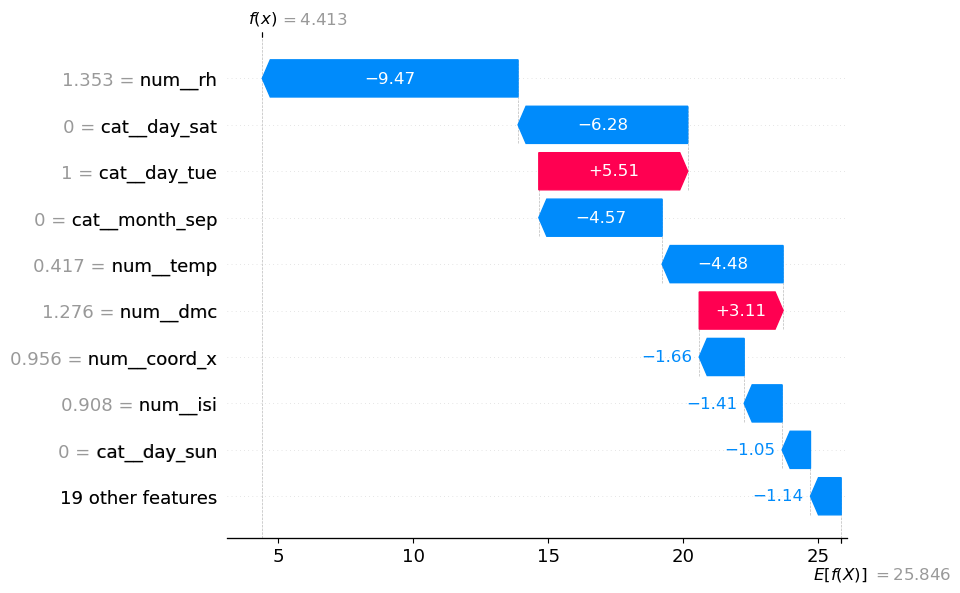

In [246]:
shap.plots.waterfall(shap_values[1])

*(Answer here.)*

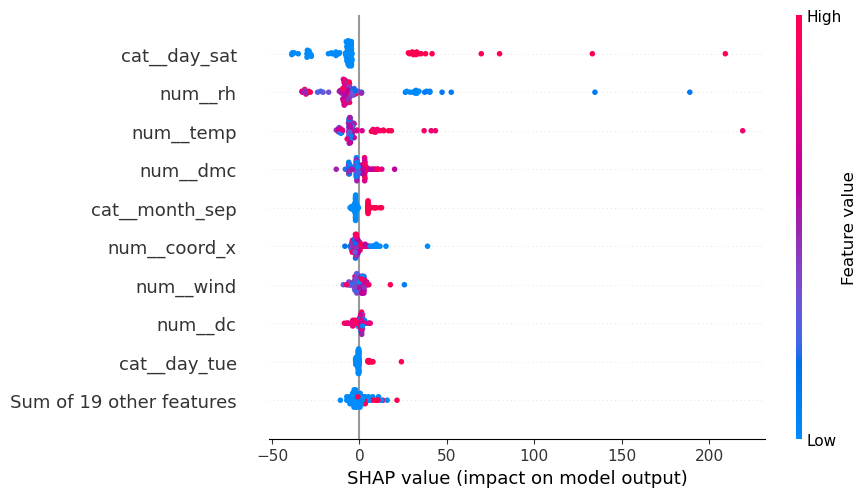

In [247]:
shap.plots.beeswarm(shap_values)

The most important features at a local level (observation 1) are the following:

1. num_rh
2. cat_day_sat
3. cat_day_tue
4. cat_month_sep
5. num_temp
6. num_dmc

The most important features at a global level are the following:

1. cat_day_sat
2. num_rh
3. num_temp
4. num_dmc

If I were to remove features from the model, I would remove:

1. cat_day_tue
2. num_dmc
3. num_wind
4. num_coord_x

Features with little contribution can add noise, slow down training, or increase overfitting. Thus, removing them simplifies the model and improves interpretability.

I would test if removing these featurs actually enhance peformance by (1) creating a new pipeline with the same preprocessing + regressor but excluding the removed features, (2) fiting it again using GridSearchCV (to tune hyperparameters), and (3) evaluating performance between the full model and the reduced model.

If performance is similar or slightly better, then the removed features were not helping, so dropping them is safe. However, if performance drops significantly, then features were actually contributing and should be kept.

## Criteria

The [rubric](./assignment_2_rubric_clean.xlsx) contains the criteria for assessment.

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/production/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at the `help` channel. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.

# Reference

Cortez,Paulo and Morais,Anbal. (2008). Forest Fires. UCI Machine Learning Repository. https://doi.org/10.24432/C5D88D.